<a href="https://colab.research.google.com/github/shanusushmita/CS4973-Applied-Multilingual-Systems/blob/main/Training_and_Validation_Loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# --- 1. Simulate Training History Data (as if from Keras/PyTorch) ---
epochs = np.arange(1, 21)
# Training Loss: Continuously drops
train_loss = 0.8 / np.log(epochs + 1.5) + np.random.normal(0, 0.05, 20)
# Validation Loss: Drops, then starts rising (overfitting)
val_loss_base = 0.7 / np.log(epochs + 1.5) + np.random.normal(0, 0.08, 20)
val_loss = val_loss_base.copy()
val_loss[10:] = val_loss[10:] + np.linspace(0, 0.2, 10) # Simulate rising validation loss after epoch 10

# Validation F1-score: Peaks around epoch 9-10
val_f1 = np.clip(1 - val_loss / 3, 0.7, 0.95)

metrics_df = pd.DataFrame({
    'Epoch': epochs,
    'Training Loss': train_loss,
    'Validation Loss': val_loss,
    'Validation F1-score': val_f1,
})

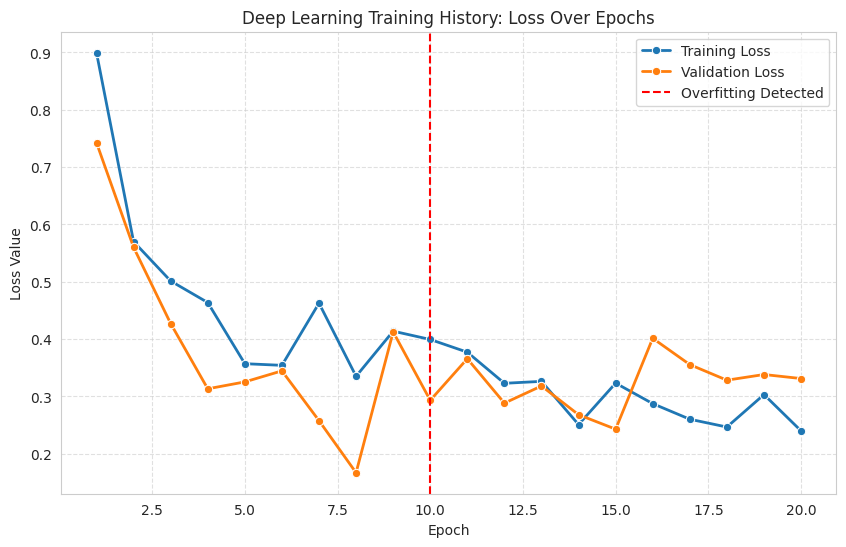

In [2]:
# Melt the DataFrame to long format for easy plotting of both metrics
loss_data = metrics_df.melt(
    id_vars='Epoch',
    value_vars=['Training Loss', 'Validation Loss'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=loss_data,
    x='Epoch',
    y='Value',
    hue='Metric',
    linewidth=2,
    marker='o'
)

plt.title('Deep Learning Training History: Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.axvline(x=10, color='red', linestyle='--', label='Overfitting Detected')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Interpretation: When the Validation Loss (orange line) stops decreasing and starts increasing
# while the Training Loss (blue line) continues to drop, the model is memorizing
# the training data rather than learning general patterns (overfitting).

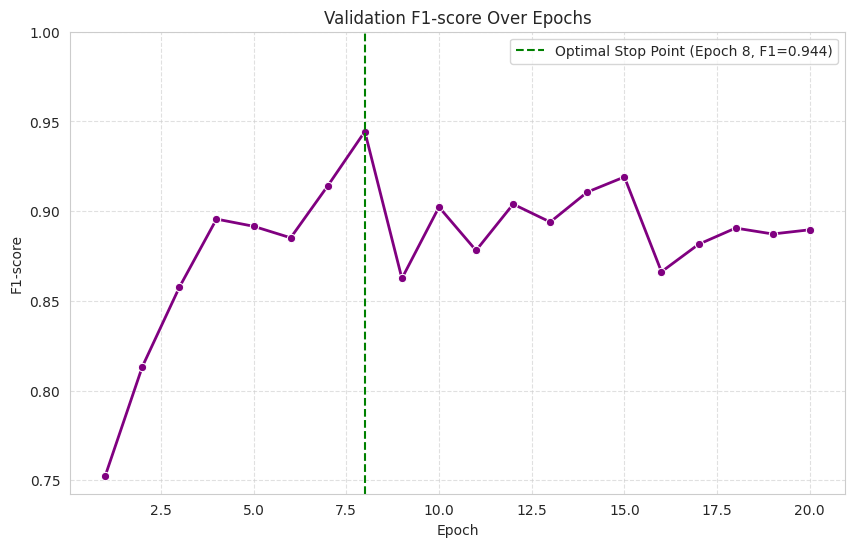

In [3]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=metrics_df,
    x='Epoch',
    y='Validation F1-score',
    linewidth=2,
    marker='o',
    color='purple'
)

max_f1_epoch = metrics_df['Validation F1-score'].idxmax() + 1 # +1 because epochs start at 1
max_f1_value = metrics_df['Validation F1-score'].max()

plt.title('Validation F1-score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.ylim(metrics_df['Validation F1-score'].min() - 0.01, 1.0)

plt.axvline(x=max_f1_epoch, color='g', linestyle='--',
            label=f'Optimal Stop Point (Epoch {max_f1_epoch}, F1={max_f1_value:.3f})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Interpretation: The Optimal Stopping Point is the epoch immediately preceding the peak F1-score
# (or the minimum validation loss), ensuring the best performance on unseen data.